# Experiment 8: Implementation and Comparative Analysis of SARSA and Q-Learning

**Software / Tools:** Python, Gymnasium, Matplotlib

**Central comparison:**

- **SARSA** — *"I update my value based on the action I actually take next."* (on-policy)
- **Q-Learning** — *"I update my value based on the best action I could take next."* (off-policy)

Both algorithms are trained on the **same** environment, seed pattern, and hyperparameters
so the comparison is fair.

```
Gymnasium Environment
        |
        v
Initialize Q-Tables
        |
        +-------------------+
        |                   |
        v                   v
     SARSA              Q-Learning
        |                   |
        v                   v
 Generate Episodes      Generate Episodes
        |                   |
        v                   v
 Update Q-Values        Update Q-Values
        |                   |
        +---------+---------+
                  |
                  v
          Compare Performance
                  |
                  v
            Summary Table
                  |
                  v
              Results
                  |
                  v
           3 Visualizations
```


## Cell 1 — Libraries, Environment & Initialization

```
Import NumPy
Import Pandas
Import Matplotlib
Import Gymnasium
      |
      v
Create FrozenLake Environment
      |
      v
Set Random Seed
      |
      v
Define:
 - Number of episodes
 - Learning rate alpha
 - Discount factor gamma
 - Exploration rate epsilon
      |
      v
Initialize SARSA Q-table
      |
      v
Initialize Q-Learning Q-table
```


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
import gymnasium as gym

%matplotlib inline
plt.rcParams['figure.facecolor'] = 'white'
np.set_printoptions(precision=3, suppress=True)

# ---------------------------------------------------------------
# Create FrozenLake Environment
# ---------------------------------------------------------------
ENV_NAME = "FrozenLake-v1"
env = gym.make(ENV_NAME, map_name="4x4", is_slippery=False)

# ---------------------------------------------------------------
# Set Random Seed
# ---------------------------------------------------------------
SEED = 42
np.random.seed(SEED)
env.reset(seed=SEED)
env.action_space.seed(SEED)

N_STATES = env.observation_space.n
N_ACTIONS = env.action_space.n
ACTION_NAMES = {0: 'Left', 1: 'Down', 2: 'Right', 3: 'Up'}
grid_desc = np.array([[cell.decode('utf-8') for cell in row] for row in env.unwrapped.desc])

# ---------------------------------------------------------------
# Define: episodes, learning rate, discount factor, exploration rate
# ---------------------------------------------------------------
EPISODES = 1000
ALPHA = 0.10       # learning rate
GAMMA = 0.99       # discount factor
EPSILON_START = 1.0
EPSILON_MIN = 0.01

# ---------------------------------------------------------------
# Initialize SARSA / Q-Learning Q-tables
# ---------------------------------------------------------------
Q_sarsa_initial = np.zeros((N_STATES, N_ACTIONS))
Q_qlearning_initial = np.zeros((N_STATES, N_ACTIONS))

env_params = pd.DataFrame({
    "Parameter": ["Environment", "States", "Actions", "Episodes", "Learning Rate (alpha)",
                  "Discount Factor (gamma)", "Initial epsilon", "Minimum epsilon"],
    "Value": [ENV_NAME, N_STATES, N_ACTIONS, EPISODES, ALPHA, GAMMA, EPSILON_START, EPSILON_MIN]
})

print("SARSA vs Q-Learning Environment Initialized")
print("=" * 45)
print("Map Layout (S=Start, F=Frozen, H=Hole, G=Goal):\n")
for row in grid_desc:
    print(' '.join(list(row)))
print()
env_params


SARSA vs Q-Learning Environment Initialized
Map Layout (S=Start, F=Frozen, H=Hole, G=Goal):

S F F F
F H F H
F F F H
H F F G



,Parameter,Value
0,Environment,FrozenLake-v1
1,States,16
2,Actions,4
3,Episodes,1000
4,Learning Rate (alpha),0.1
5,Discount Factor (gamma),0.99
6,Initial epsilon,1.0
7,Minimum epsilon,0.01


## Cell 2 — Algorithms & Policies

```
Part A: SARSA                     Part B: Q-Learning
--------------                    ------------------
Initialize Q(s,a)                 Initialize Q(s,a)
      |                                 |
      v                                 v
Choose action (epsilon-greedy)    Choose action (epsilon-greedy)
      |                                 |
      v                                 v
Take action                       Take action
      |                                 |
      v                                 v
Observe R, S'                     Observe R, S'
      |                                 |
      v                                 v
Choose next action A'             Select maximum Q(S', a)
      |                                 |
      v                                 v
Update Q(S,A)                     Update Q(S,A)
      |                                 |
      v                                 v
Move to S', A'                    Move to S'
      |                                 |
      v                                 v
Repeat until episode ends         Repeat until episode ends
```

**SARSA update** (on-policy — uses the actual next action A' selected by the policy):

$$Q(S,A) \leftarrow Q(S,A) + \alpha \Big[ R + \gamma\, Q(S', A') - Q(S,A) \Big]$$

**Q-Learning update** (off-policy — uses the maximum estimated future action value):

$$Q(S,A) \leftarrow Q(S,A) + \alpha \Big[ R + \gamma \max_{a} Q(S', a) - Q(S,A) \Big]$$


In [2]:
def epsilon_greedy(Q, state, epsilon, rng):
    if rng.random() < epsilon:
        return int(rng.integers(N_ACTIONS))
    return int(np.argmax(Q[state]))


def get_epsilon(episode, episodes, eps_start, eps_min):
    return max(eps_min, eps_start - (eps_start - eps_min) * (episode / episodes))


In [3]:
# =================================================================
# Part A: SARSA (on-policy TD control)
# =================================================================

def run_sarsa(env, episodes, alpha, gamma, eps_start, eps_min, seed):
    rng = np.random.default_rng(seed)
    Q = np.zeros((N_STATES, N_ACTIONS))

    episode_rewards = []
    episode_steps = []

    start_time = time.perf_counter()
    for ep in range(episodes):
        epsilon = get_epsilon(ep, episodes, eps_start, eps_min)

        # ---- Choose action using epsilon-greedy ----
        state, _ = env.reset()
        action = epsilon_greedy(Q, state, epsilon, rng)

        done = False
        total_reward = 0.0
        steps = 0

        while not done and steps < 100:
            # ---- Take action / Observe R, S' ----
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated

            # ---- Choose next action A' ----
            next_action = None if done else epsilon_greedy(Q, next_state, epsilon, rng)

            # ---- Update Q(S,A) using the ACTUAL next action ----
            td_target = reward + gamma * (0.0 if done else Q[next_state, next_action])
            Q[state, action] += alpha * (td_target - Q[state, action])

            total_reward += reward
            steps += 1

            # ---- Move to S', A' ----
            state = next_state
            action = next_action

        episode_rewards.append(total_reward)
        episode_steps.append(steps)

    exec_time_ms = (time.perf_counter() - start_time) * 1000

    return {
        "Q": Q,
        "episode_rewards": episode_rewards,
        "episode_steps": episode_steps,
        "exec_time_ms": exec_time_ms,
    }


sarsa_result = run_sarsa(env, EPISODES, ALPHA, GAMMA, EPSILON_START, EPSILON_MIN, seed=SEED)
print(f"SARSA training complete. Execution time: {sarsa_result['exec_time_ms']:.2f} ms")


SARSA training complete. Execution time: 119.32 ms


In [4]:
# =================================================================
# Part B: Q-Learning (off-policy TD control)
# =================================================================

def run_q_learning(env, episodes, alpha, gamma, eps_start, eps_min, seed):
    rng = np.random.default_rng(seed)
    Q = np.zeros((N_STATES, N_ACTIONS))

    episode_rewards = []
    episode_steps = []

    start_time = time.perf_counter()
    for ep in range(episodes):
        epsilon = get_epsilon(ep, episodes, eps_start, eps_min)

        state, _ = env.reset()
        done = False
        total_reward = 0.0
        steps = 0

        while not done and steps < 100:
            # ---- Choose action using epsilon-greedy ----
            action = epsilon_greedy(Q, state, epsilon, rng)

            # ---- Take action / Observe R, S' ----
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated

            # ---- Select maximum Q(S', a) ----
            best_next_value = 0.0 if done else np.max(Q[next_state])

            # ---- Update Q(S,A) using the MAXIMUM estimated action value ----
            td_target = reward + gamma * best_next_value
            Q[state, action] += alpha * (td_target - Q[state, action])

            total_reward += reward
            steps += 1

            # ---- Move to S' ----
            state = next_state

        episode_rewards.append(total_reward)
        episode_steps.append(steps)

    exec_time_ms = (time.perf_counter() - start_time) * 1000

    return {
        "Q": Q,
        "episode_rewards": episode_rewards,
        "episode_steps": episode_steps,
        "exec_time_ms": exec_time_ms,
    }


qlearning_result = run_q_learning(env, EPISODES, ALPHA, GAMMA, EPSILON_START, EPSILON_MIN, seed=SEED + 1)
print(f"Q-Learning training complete. Execution time: {qlearning_result['exec_time_ms']:.2f} ms")


Q-Learning training complete. Execution time: 173.87 ms


## Cell 3 — Summary Table

In [5]:
def find_convergence_episode(rewards, window=50, warmup=100, threshold=0.01):
    """First episode after which the rolling-average reward stops moving
    by more than `threshold` for the rest of training."""
    rolling = pd.Series(rewards).rolling(window=window, min_periods=1).mean()
    diffs = rolling.diff().abs()
    below = diffs < threshold
    for i in range(warmup, len(below)):
        if below.iloc[i:].all():
            return i + 1
    return len(rewards)


def summarize(result, window=50):
    rewards = result["episode_rewards"]
    last_100 = rewards[-100:]
    return {
        "avg_reward": float(np.mean(last_100)),
        "success_rate": float(np.mean(np.array(last_100) > 0) * 100),
        "final_q_value": float(result["Q"].mean()),
        "convergence_episode": find_convergence_episode(rewards, window=window),
        "exec_time_ms": result["exec_time_ms"],
        "rolling_reward": pd.Series(rewards).rolling(window=window, min_periods=1).mean(),
    }


sarsa_stats = summarize(sarsa_result)
qlearning_stats = summarize(qlearning_result)

summary_table = pd.DataFrame({
    "Metric": ["Episodes", "Average Reward", "Success Rate (%)", "Final Q-Value",
               "Convergence Episode", "Execution Time (ms)"],
    "SARSA": [EPISODES, f"{sarsa_stats['avg_reward']:.2f}", f"{sarsa_stats['success_rate']:.1f}",
              f"{sarsa_stats['final_q_value']:.3f}", sarsa_stats['convergence_episode'],
              f"{sarsa_stats['exec_time_ms']:.0f}"],
    "Q-Learning": [EPISODES, f"{qlearning_stats['avg_reward']:.2f}", f"{qlearning_stats['success_rate']:.1f}",
                   f"{qlearning_stats['final_q_value']:.3f}", qlearning_stats['convergence_episode'],
                   f"{qlearning_stats['exec_time_ms']:.0f}"],
})

print("Main Summary Table\n")
display(summary_table)

# ---------------------------------------------------------------
# Policy Comparison
# ---------------------------------------------------------------
sarsa_policy = np.argmax(sarsa_result["Q"], axis=1)
qlearning_policy = np.argmax(qlearning_result["Q"], axis=1)

policy_comparison = pd.DataFrame({
    "State": np.arange(N_STATES),
    "SARSA Best Action": [ACTION_NAMES[a] for a in sarsa_policy],
    "Q-Learning Best Action": [ACTION_NAMES[a] for a in qlearning_policy],
})

print("\nPolicy Comparison\n")
policy_comparison


Main Summary Table



,Metric,SARSA,Q-Learning
0,Episodes,1000,1000
1,Average Reward,0.96,0.94
2,Success Rate (%),96.0,94.0
3,Final Q-Value,0.283,0.426
4,Convergence Episode,989,997
5,Execution Time (ms),119,174



Policy Comparison



,State,SARSA Best Action,Q-Learning Best Action
0,0,Right,Right
1,1,Right,Right
2,2,Down,Down
3,3,Left,Left
4,4,Down,Up
5,5,Left,Left
6,6,Down,Down
7,7,Left,Left
8,8,Right,Right
9,9,Down,Right


## Cell 4 — Results & Comparative Analysis

In [6]:
better_reward = "SARSA" if sarsa_stats["avg_reward"] > qlearning_stats["avg_reward"] else (
    "Q-Learning" if qlearning_stats["avg_reward"] > sarsa_stats["avg_reward"] else "Tie")
better_success = "SARSA" if sarsa_stats["success_rate"] > qlearning_stats["success_rate"] else (
    "Q-Learning" if qlearning_stats["success_rate"] > sarsa_stats["success_rate"] else "Tie")
faster_algorithm = "SARSA" if sarsa_stats["exec_time_ms"] < qlearning_stats["exec_time_ms"] else "Q-Learning"

print("=" * 41)
print("       SARSA vs Q-LEARNING RESULTS")
print("=" * 41)
print()
print(f"SARSA Average Reward       : {sarsa_stats['avg_reward']:.2f}")
print(f"Q-Learning Average Reward  : {qlearning_stats['avg_reward']:.2f}")
print()
print(f"SARSA Success Rate         : {sarsa_stats['success_rate']:.1f} %")
print(f"Q-Learning Success Rate    : {qlearning_stats['success_rate']:.1f} %")
print()
print(f"SARSA Execution Time       : {sarsa_stats['exec_time_ms']:.0f} ms")
print(f"Q-Learning Execution Time  : {qlearning_stats['exec_time_ms']:.0f} ms")
print()
print(f"Better Average Reward      : {better_reward}")
print(f"Better Success Rate        : {better_success}")
print(f"Faster Algorithm           : {faster_algorithm}")
print()
print("Overall Observation:")
print("Both algorithms learn an effective policy,")
print("but their learning behavior differs because")
print("SARSA follows the selected next action while")
print("Q-Learning uses the maximum estimated action value.")


       SARSA vs Q-LEARNING RESULTS

SARSA Average Reward       : 0.96
Q-Learning Average Reward  : 0.94

SARSA Success Rate         : 96.0 %
Q-Learning Success Rate    : 94.0 %

SARSA Execution Time       : 119 ms
Q-Learning Execution Time  : 174 ms

Better Average Reward      : SARSA
Better Success Rate        : SARSA
Faster Algorithm           : SARSA

Overall Observation:
Both algorithms learn an effective policy,
but their learning behavior differs because
SARSA follows the selected next action while
Q-Learning uses the maximum estimated action value.


## Cell 5 — Visualizations

Three genuinely different chart types, each answering a different question:

| Visualization | What it tells us |
|---|---|
| Line Chart | How does learning progress? |
| Bar Chart | Which algorithm performs better overall? |
| Heatmap | What has each algorithm learned? |


### Visualization 1: Learning Curve (Line Chart)

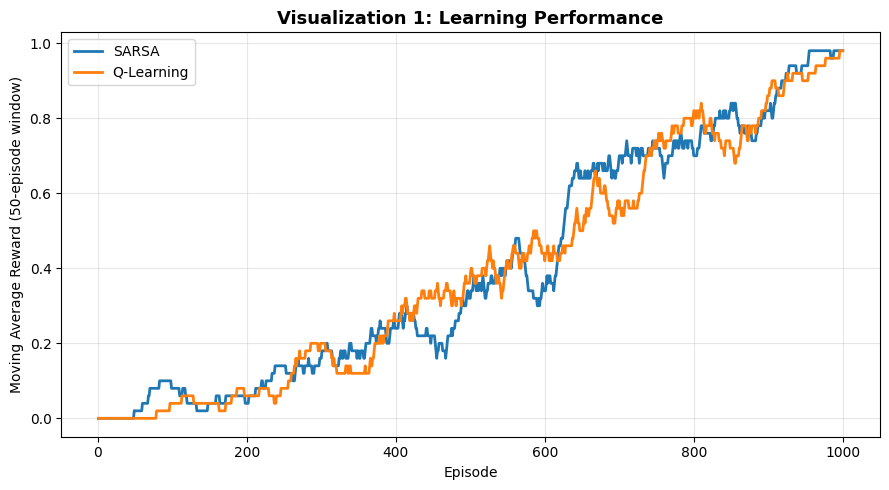

In [7]:
fig, ax = plt.subplots(figsize=(9, 5))

episodes_axis = np.arange(1, EPISODES + 1)
ax.plot(episodes_axis, sarsa_stats["rolling_reward"], color="tab:blue", linewidth=2, label="SARSA")
ax.plot(episodes_axis, qlearning_stats["rolling_reward"], color="tab:orange", linewidth=2, label="Q-Learning")

ax.set_xlabel("Episode")
ax.set_ylabel("Moving Average Reward (50-episode window)")
ax.set_title("Visualization 1: Learning Performance", fontsize=13, fontweight="bold")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


### Visualization 2: Performance Comparison (Grouped Bar Chart)

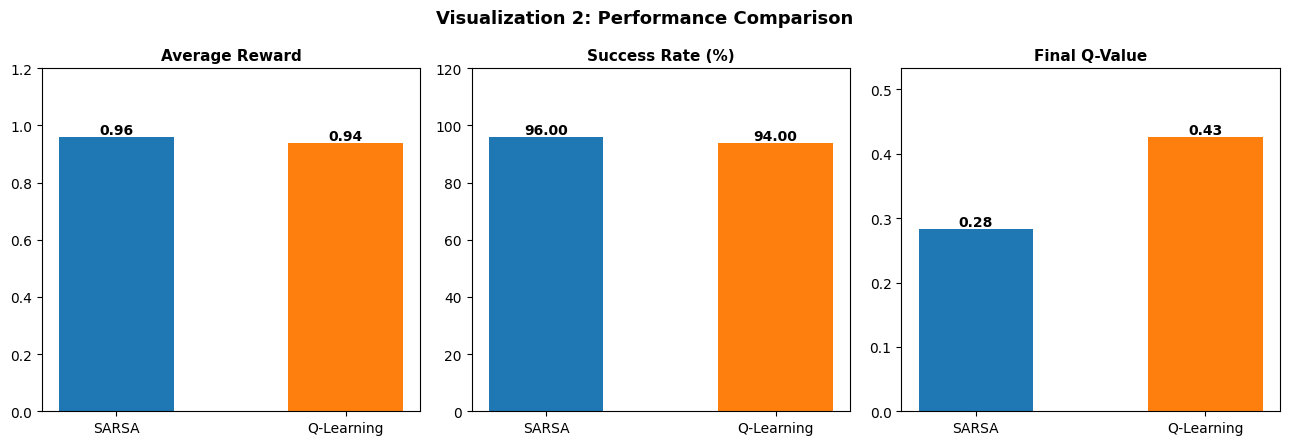

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))

metrics = [
    ("Average Reward", [sarsa_stats["avg_reward"], qlearning_stats["avg_reward"]]),
    ("Success Rate (%)", [sarsa_stats["success_rate"], qlearning_stats["success_rate"]]),
    ("Final Q-Value", [sarsa_stats["final_q_value"], qlearning_stats["final_q_value"]]),
]
labels = ["SARSA", "Q-Learning"]
colors = ["tab:blue", "tab:orange"]

for ax, (title, values) in zip(axes, metrics):
    bars = ax.bar(labels, values, color=colors, width=0.5)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
                 f"{val:.2f}", ha="center", va="bottom", fontweight="bold")
    ax.set_title(title, fontsize=11, fontweight="bold")
    top = max(values) if max(values) > 0 else 1
    ax.set_ylim(0, top * 1.25)

fig.suptitle("Visualization 2: Performance Comparison", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


### Visualization 3: Learned Q-Value Representation (Heatmap)

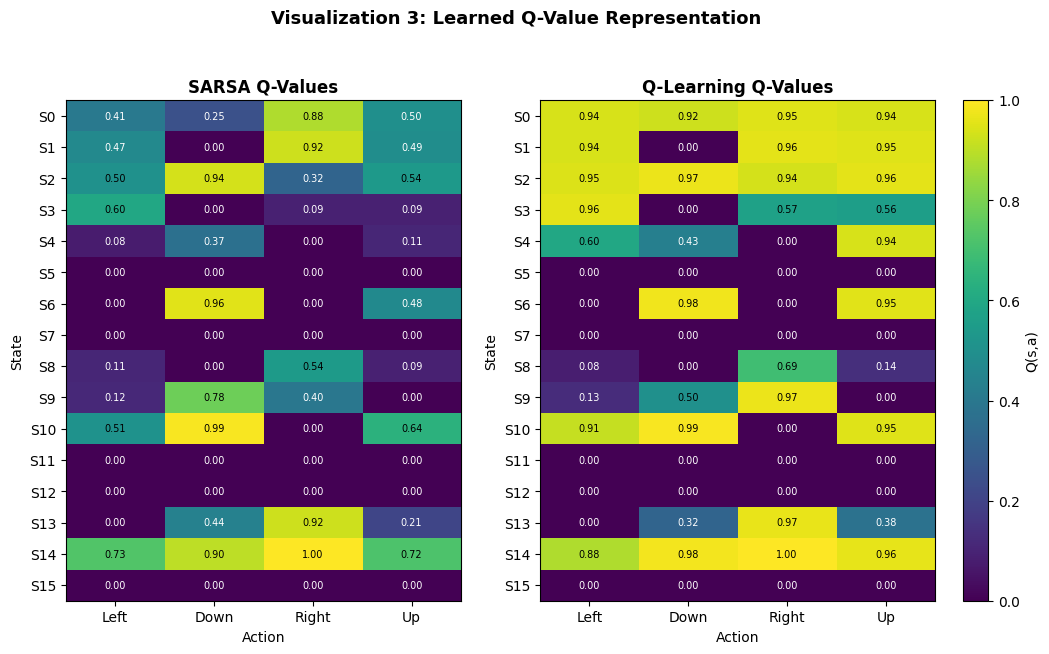

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6.5))

Q_sarsa = sarsa_result["Q"]
Q_qlearning = qlearning_result["Q"]
vmin = min(Q_sarsa.min(), Q_qlearning.min())
vmax = max(Q_sarsa.max(), Q_qlearning.max())

action_labels = [ACTION_NAMES[a] for a in range(N_ACTIONS)]

for ax, Q, title in zip(axes, [Q_sarsa, Q_qlearning], ["SARSA Q-Values", "Q-Learning Q-Values"]):
    im = ax.imshow(Q, cmap="viridis", vmin=vmin, vmax=vmax, aspect="auto")
    for r in range(N_STATES):
        for c in range(N_ACTIONS):
            ax.text(c, r, f"{Q[r, c]:.2f}", ha="center", va="center",
                     fontsize=7, color="white" if Q[r, c] < (vmin + vmax) / 2 else "black")
    ax.set_xticks(range(N_ACTIONS))
    ax.set_xticklabels(action_labels)
    ax.set_yticks(range(N_STATES))
    ax.set_yticklabels([f"S{s}" for s in range(N_STATES)])
    ax.set_xlabel("Action")
    ax.set_ylabel("State")
    ax.set_title(title, fontsize=12, fontweight="bold")

fig.colorbar(im, ax=axes, fraction=0.035, pad=0.03, label="Q(s,a)")
fig.suptitle("Visualization 3: Learned Q-Value Representation", fontsize=13, fontweight="bold", y=1.02)
plt.show()
